# Customer Churn Prediction — Model Training Notebook

This notebook builds an end-to-end machine learning pipeline to predict customer churn (Yes/No), following all required steps: data understanding, cleaning, EDA, preprocessing, model training, evaluation, and saving the final model for deployment in a Streamlit app.

## 1. Import Libraries

We import libraries for data handling, visualization, preprocessing, model training, evaluation, and model saving.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Model saving
import joblib

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load and Understand the Data

We load the dataset and inspect its structure: first/last rows, shape, column names, data types, and descriptive statistics.

In [2]:
df = pd.read_csv("customer_churn_data.csv")

print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print(f"\nShape: {df.shape[0]} rows, {df.shape[1]} columns")

print("\nColumn names:", df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset info:")
df.info()

print("\nDescriptive statistics (numeric):")
display(df.describe())

print("\nDescriptive statistics (categorical):")
display(df.describe(include='object'))

First 5 rows:


,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,CUST10001,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,CUST10002,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,CUST10003,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,CUST10004,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,CUST10005,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes



Last 5 rows:


,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
1215,CUST10722,76,Female,South,48,61.37,2896.21,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,1,1,93.5,Yes
1216,CUST11129,53,Male,East,9,86.36,716.92,One year,Fiber optic,Yes,Yes,Yes,NaN,0,2,387.3,No
1217,CUST10400,37,Female,South,69,78.02,5132.74,One year,Fiber optic,No,Yes,Yes,Bank transfer,1,1,387.6,No
1218,CUST10695,23,Male,South,56,84.87,4533.03,One year,Fiber optic,No,No,No,Bank transfer,2,3,304.3,No
1219,CUST10110,62,Female,West,45,89.86,3730.49,Two year,Fiber optic,No,Yes,Yes,Electronic check,0,4,308.0,No



Shape: 1220 rows, 17 columns

Column names: ['customer_id', 'age', 'gender', 'region', 'tenure_months', 'monthly_charges', 'total_charges', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'paperless_billing', 'payment_method', 'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb', 'churn']

Data types:
customer_id                 object
age                          int64
gender                      object
region                      object
tenure_months                int64
monthly_charges            float64
total_charges              float64
contract_type               object
internet_service            object
tech_support                object
online_security             object
paperless_billing           object
payment_method              object
num_support_calls            int64
late_payments_last_year      int64
avg_monthly_usage_gb       float64
churn                       object
dtype: object

Dataset info:
<class 'pandas.core.frame.Data

,age,tenure_months,monthly_charges,total_charges,num_support_calls,late_payments_last_year,avg_monthly_usage_gb
count,1220.000000,1220.000000,1198.000000,1187.000000,1220.000000,1220.000000,1196.000000
mean,49.309016,36.956557,66.509474,2421.133437,1.759836,1.143443,214.370569
std,18.125678,20.512560,24.295211,1681.896803,1.298902,1.078501,143.970148
min,18.000000,1.000000,18.000000,12.600000,0.000000,0.000000,0.000000
25%,34.000000,19.000000,50.047500,1011.740000,1.000000,0.000000,116.075000
50%,49.500000,38.000000,69.020000,2120.450000,2.000000,1.000000,206.300000
75%,65.000000,55.000000,86.465000,3619.765000,3.000000,2.000000,322.775000
max,80.000000,72.000000,118.580000,7579.280000,8.000000,6.000000,600.600000



Descriptive statistics (categorical):


,customer_id,gender,region,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,churn
count,1220,1220,1220,1220,1220,1194,1199,1220,1200,1220
unique,1200,2,4,3,3,3,3,2,4,2
top,CUST10460,Male,South,Month-to-month,Fiber optic,No,No,Yes,Electronic check,Yes
freq,2,625,353,679,563,582,539,757,400,688


**Observations:**
- The dataset contains 1,220 rows and 17 columns.
- Data types look correct: numeric columns (`age`, `tenure_months`, `monthly_charges`, `total_charges`, `num_support_calls`, `late_payments_last_year`, `avg_monthly_usage_gb`) are `int64`/`float64`, and the rest are categorical (`object`).
- Some numeric columns (`monthly_charges`, `total_charges`, `avg_monthly_usage_gb`) show fewer non-null values than the total row count, hinting at missing values that we will investigate next.

## 3. Data Quality Checks

We check for missing values, duplicate records, unique values in categorical columns, and the class balance of the target variable.

In [3]:
# Missing values in every column
print("Missing values per column:")
print(df.isnull().sum())

print("\nMissing values (%):")
print((df.isnull().sum() / len(df) * 100).round(2))

# Duplicate records
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Duplicate customer_ids specifically (important! customer_id should be unique)
print(f"Duplicate customer_id count: {df['customer_id'].duplicated().sum()}")

# Unique values in categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customer_id')  # not meaningful to show uniques for ID

print("\nUnique values in categorical columns:")
for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")

# Class distribution of target
print("\nChurn class distribution:")
print(df['churn'].value_counts())
print(df['churn'].value_counts(normalize=True).round(3) * 100, "%")

Missing values per column:
customer_id                 0
age                         0
gender                      0
region                      0
tenure_months               0
monthly_charges            22
total_charges              33
contract_type               0
internet_service            0
tech_support               26
online_security            21
paperless_billing           0
payment_method             20
num_support_calls           0
late_payments_last_year     0
avg_monthly_usage_gb       24
churn                       0
dtype: int64

Missing values (%):
customer_id                0.00
age                        0.00
gender                     0.00
region                     0.00
tenure_months              0.00
monthly_charges            1.80
total_charges              2.70
contract_type              0.00
internet_service           0.00
tech_support               2.13
online_security            1.72
paperless_billing          0.00
payment_method             1.64
num_support_c

**Observations:**
- Missing values are found in three numeric columns — `monthly_charges` (1.8%), `total_charges` (2.7%), `avg_monthly_usage_gb` (2.0%) — and three categorical columns — `tech_support` (2.1%), `online_security` (1.7%), `payment_method` (1.6%). All are under 3%, which is manageable through imputation.
- There are 20 duplicate rows, and all 20 also share duplicate `customer_id` values — meaning these are exact duplicate customer records (likely a data-entry error) rather than different customers who coincidentally share the same feature values.
- Categorical columns contain clean, consistent values with no typos. Note that `"No internet service"` appears in `tech_support` and `online_security` — this is a **valid category** (customers without internet naturally cannot have these services), not a missing value.
- The target class `churn` is mildly imbalanced: **56.4% Yes, 43.6% No**. This is balanced enough that accuracy remains meaningful, but we will still track precision/recall/F1 closely.

## 4. Data Cleaning

Based on the data quality checks above, we make the following cleaning decisions.

In [4]:
# --- Decision 1: Duplicate records ---
# 20 rows have duplicate customer_id AND are full duplicates -> safe to drop
print(f"Rows before dropping duplicates: {len(df)}")
df = df.drop_duplicates()
print(f"Rows after dropping duplicates: {len(df)}")

# Double check no duplicate customer_ids remain
print(f"Remaining duplicate customer_ids: {df['customer_id'].duplicated().sum()}")

# --- Decision 2: customer_id column ---
# customer_id is just a unique identifier with no predictive value.
# We will keep it in the dataframe for reference, but DROP it before training
# (this is done explicitly when creating X, in Step 6).

# --- Decision 3 & 4: Missing values (numeric + categorical) ---
# We will NOT manually fill missing values right here on the full dataset.
# Reason: if we impute now (before the train-test split), statistics like the median
# would be calculated using the test set too -> this is "data leakage".
# Instead, missing values are handled INSIDE the preprocessing pipeline (Step 8),
# which is fit ONLY on the training data. This is best practice.

Rows before dropping duplicates: 1220
Rows after dropping duplicates: 1200
Remaining duplicate customer_ids: 0


**Data Cleaning Decisions:**
1. **Duplicates**: Dropped 20 duplicate rows (same `customer_id` appeared twice with identical data — likely a data entry error). Dataset reduced from 1,220 to 1,200 rows.
2. **`customer_id`**: Not used as a model feature since it is a unique identifier with no predictive signal — it is excluded when building `X` in Step 6.
3. **Missing numeric values** (`monthly_charges`, `total_charges`, `avg_monthly_usage_gb`): Will be imputed with the **median** (robust to outliers) inside the preprocessing pipeline, fit only on training data to avoid data leakage.
4. **Missing categorical values** (`tech_support`, `online_security`, `payment_method`): Will be imputed with the **most frequent value (mode)** inside the pipeline. `"No internet service"` is a legitimate category and requires no special handling.

## 5. Exploratory Data Analysis

We visualize the target distribution and its relationship with key features.

### 5.1 Churn Class Distribution

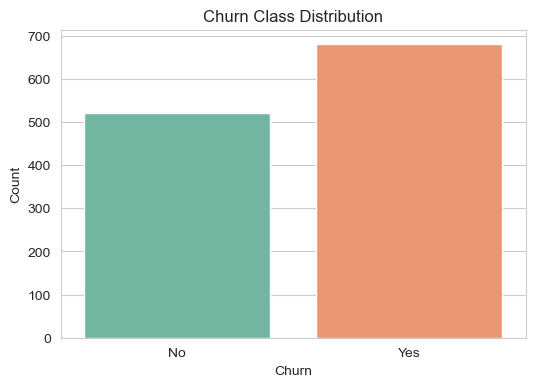

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churn', hue='churn', palette='Set2', legend=False)
plt.title('Churn Class Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

**Observation:** Churn is mildly imbalanced — slightly more customers churned (Yes) than stayed (No), but not severely enough to require resampling techniques.

### 5.2 Churn by Contract Type

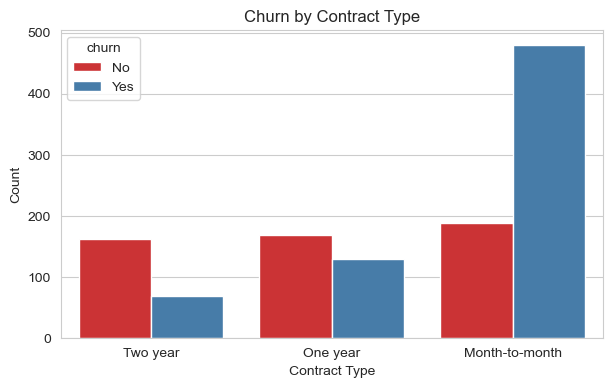

In [6]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='contract_type', hue='churn', palette='Set1')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

**Observation:** Month-to-month customers show noticeably higher churn compared to One-year and Two-year contract holders, suggesting that longer commitments improve retention.

### 5.3 Churn by Internet Service

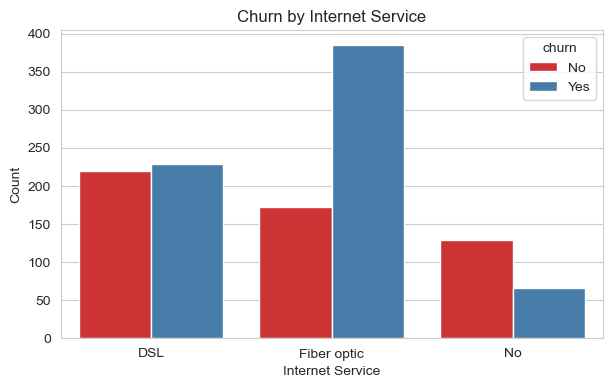

In [7]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='internet_service', hue='churn', palette='Set1')
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

**Observation:** Fiber optic customers churn more than DSL customers, possibly due to higher cost or higher service expectations for a premium connection.

### 5.4 Monthly Charges Distribution

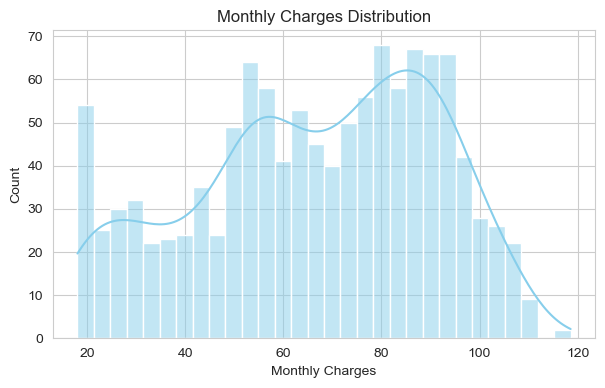

In [8]:
plt.figure(figsize=(7,4))
sns.histplot(df['monthly_charges'].dropna(), kde=True, bins=30, color='skyblue')
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.show()

**Observation:** Monthly charges are spread fairly widely across the customer base, roughly between $18 and $118, without extreme outliers.

### 5.5 Tenure Distribution

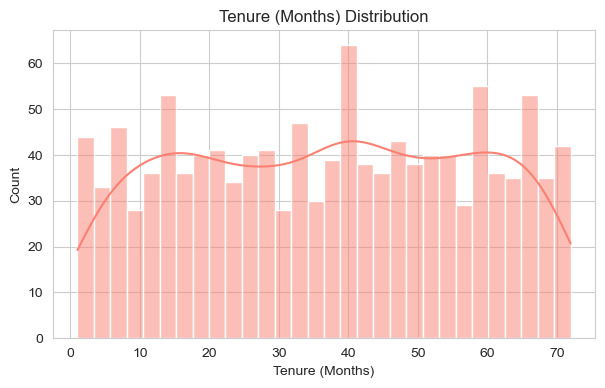

In [9]:
plt.figure(figsize=(7,4))
sns.histplot(df['tenure_months'].dropna(), kde=True, bins=30, color='salmon')
plt.title('Tenure (Months) Distribution')
plt.xlabel('Tenure (Months)')
plt.show()

**Observation:** Tenure is spread fairly evenly from 1 to 72 months, indicating a healthy mix of new and long-standing customers in the dataset.

### 5.6 Additional Visualization — Support Calls vs Churn

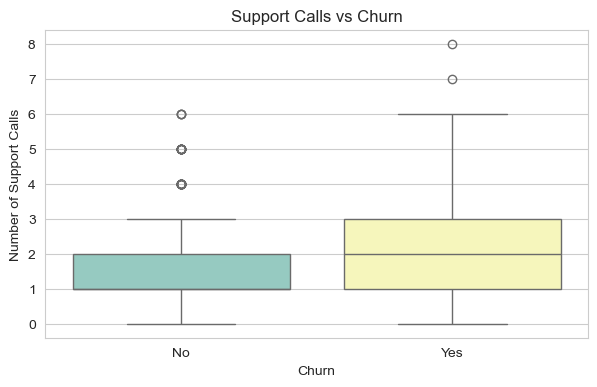

In [10]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='churn', y='num_support_calls', hue='churn', palette='Set3', legend=False)
plt.title('Support Calls vs Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Support Calls')
plt.show()

**Observation:** Customers who churned tend to have made more support calls on average, suggesting that frustration with service issues is a meaningful churn signal.

## 6. Prepare Features and Target

We separate the input features (`X`) from the target (`y`), and identify which columns are numeric vs. categorical.

In [11]:
# Drop customer_id (not useful for prediction) and separate target
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn'].map({'Yes': 1, 'No': 0})   # encode target as 0/1

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("\ny value counts:\n", y.value_counts())

Numeric columns: ['age', 'tenure_months', 'monthly_charges', 'total_charges', 'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb']
Categorical columns: ['gender', 'region', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'paperless_billing', 'payment_method']

X shape: (1200, 15)
y shape: (1200,)

y value counts:
 churn
1    680
0    520
Name: count, dtype: int64


**Note:** `churn` is encoded as `1 = Yes (churned)` and `0 = No (retained)`,so that churn is clearly treated as the positive class when calculating precision, recall and F1 score.This also makes `1` the positive class for precision/recall calculations, which is the natural convention for churn prediction.

## 7. Train-Test Split

We split the cleaned data into training (80%) and testing (20%) sets, using stratification to preserve the churn ratio in both sets.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ensures same churn ratio in train and test sets
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTrain churn ratio:\n", y_train.value_counts(normalize=True))
print("\nTest churn ratio:\n", y_test.value_counts(normalize=True))

X_train shape: (960, 15)
X_test shape: (240, 15)

Train churn ratio:
 churn
1    0.566667
0    0.433333
Name: proportion, dtype: float64

Test churn ratio:
 churn
1    0.566667
0    0.433333
Name: proportion, dtype: float64


**Notes:**
- `test_size=0.2` → 80% for training, 20% for testing.
- `random_state=42` → fixes the random seed so the split is reproducible.
- `stratify=y` → ensures the churn ratio (56.7% / 43.3%) is preserved identically in both the training and test sets, which is important since the target is not perfectly balanced.

## 8. Preprocessing

We build a `ColumnTransformer` that applies the right preprocessing to numeric and categorical columns separately, so it can be combined with any model into a single pipeline.

In [13]:
# Numeric pipeline: fill missing with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: fill missing with mode, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both into a single preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


**Explanation:**
- **Numeric features**: missing values are filled with the **median** (robust to outliers), then scaled with `StandardScaler` so all numeric features are on a comparable scale — important for distance/magnitude-sensitive models like Logistic Regression.
- **Categorical features**: missing values are filled with the **most frequent value (mode)**, then converted to numeric form with `OneHotEncoder`. `handle_unknown='ignore'` ensures the pipeline won't crash if it encounters a category at prediction time that wasn't seen during training.
- Wrapping both in a single `ColumnTransformer` guarantees the **same preprocessing is applied consistently** at training time and at prediction time (a requirement of this assignment).

## 9. Train At Least Two Models

We train two different classification algorithms — Logistic Regression (linear) and Random Forest (tree-based ensemble) — each wrapped in a full pipeline with the shared preprocessor.

In [14]:
# --- Model 1: Logistic Regression ---
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
print("Logistic Regression trained successfully!")

# --- Model 2: Random Forest ---
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
print("Random Forest trained successfully!")

Logistic Regression trained successfully!
Random Forest trained successfully!


**Note:** Because the preprocessor is included inside each pipeline, `.fit(X_train, y_train)` fits the imputers/scaler/encoder **only on the training data**, preventing any information from the test set leaking into preprocessing.

## 10. Model Evaluation

For each model we calculate Accuracy, Precision, Recall, F1 Score, the Confusion Matrix, and the full Classification Report.

===== Logistic Regression =====
Accuracy:  0.7583
Precision: 0.7671
Recall:    0.8235
F1 Score:  0.7943

Confusion Matrix:
[[ 70  34]
 [ 24 112]]


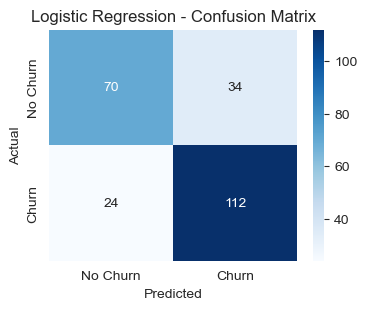


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.67      0.71       104
           1       0.77      0.82      0.79       136

    accuracy                           0.76       240
   macro avg       0.76      0.75      0.75       240
weighted avg       0.76      0.76      0.76       240

===== Random Forest =====
Accuracy:  0.7125
Precision: 0.7410
Recall:    0.7574
F1 Score:  0.7491

Confusion Matrix:
[[ 68  36]
 [ 33 103]]


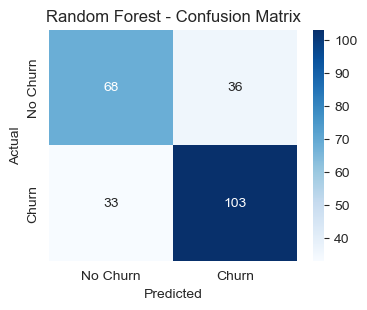


Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       104
           1       0.74      0.76      0.75       136

    accuracy                           0.71       240
   macro avg       0.71      0.71      0.71       240
weighted avg       0.71      0.71      0.71       240



In [15]:
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"===== {name} =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1}

# Evaluate both models
results = []
results.append(evaluate_model("Logistic Regression", lr_pipeline, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_pipeline, X_test, y_test))

### Model Comparison Table

In [16]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.set_index('Model')
display(comparison_df.round(4))

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.7583,0.7671,0.8235,0.7943
Random Forest,0.7125,0.7410,0.7574,0.7491


**Results:**

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Logistic Regression | 0.7583 | 0.7671 | 0.8235 | **0.7943** |
| Random Forest | 0.7125 | 0.7410 | 0.7574 | 0.7491 |

Logistic Regression outperforms Random Forest on **every metric**.

## 11. Select the Final Model

**Final Model Selection: Logistic Regression**

Logistic Regression is selected as the final model because it outperforms Random Forest on every evaluation metric — not just training/testing accuracy (Accuracy: 0.758 vs 0.713, Precision: 0.767 vs 0.741, Recall: 0.824 vs 0.757, F1: 0.794 vs 0.749). Recall is especially important for churn prediction, since correctly identifying as many true churners as possible allows the business to intervene proactively — and Logistic Regression achieves the higher recall here. With a moderately sized training set (960 rows), the simpler linear model generalizes better.

In [17]:
final_pipeline = lr_pipeline
print("Final selected model: Logistic Regression")

Final selected model: Logistic Regression


## 12. Save the Final Model

The complete pipeline (preprocessing + trained model) is saved as a single `.pkl` file so it can be loaded directly by the Streamlit app without needing to redefine any preprocessing logic.

In [18]:
joblib.dump(final_pipeline, 'churn_pipeline.pkl')
print("Model saved as churn_pipeline.pkl")

Model saved as churn_pipeline.pkl


## 13. Reload and Test the Saved Model

We reload the saved pipeline and run one manual prediction to confirm the saved file works correctly end-to-end.

In [19]:
# Reload the saved pipeline
loaded_pipeline = joblib.load('churn_pipeline.pkl')

# Create one manual sample customer (using real column names/values)
sample_customer = pd.DataFrame([{
    'age': 35,
    'gender': 'Female',
    'region': 'East',
    'tenure_months': 5,
    'monthly_charges': 85.5,
    'total_charges': 420.0,
    'contract_type': 'Month-to-month',
    'internet_service': 'Fiber optic',
    'tech_support': 'No',
    'online_security': 'No',
    'paperless_billing': 'Yes',
    'payment_method': 'Electronic check',
    'num_support_calls': 4,
    'late_payments_last_year': 2,
    'avg_monthly_usage_gb': 300.0
}])

prediction = loaded_pipeline.predict(sample_customer)
probability = loaded_pipeline.predict_proba(sample_customer)

print("Prediction (0=No, 1=Yes):", prediction[0])
print("Churn Probability:", probability[0][1].round(3))
print("Prediction Label:", "Yes" if prediction[0] == 1 else "No")

Prediction (0=No, 1=Yes): 1
Churn Probability: 0.989
Prediction Label: Yes


**Observation:** The reloaded pipeline correctly predicts **"Yes" (churn)** with a probability of **98.9%** for this sample customer — a Month-to-month customer with low tenure, no tech support, and multiple support calls, which matches the churn-risk patterns identified during EDA. This confirms the saved `.pkl` file works correctly and is ready to be used by the Streamlit app.